# `transient_step_core` Notebook Demo

This notebook exercises [`transient_step_core.dsl.py`](./examples/transient_step_core.dsl.py) through the semantic runtime.

What it shows:
- the kernel compiles through the current simpyhls flow
- the Python DSL, HIR simulation, and LIR simulation stay equivalent at every timestep
- time-domain responses for a few simple circuits are rendered inline as annotated SVG plots

This notebook intentionally uses only standard-library helpers plus the simpyhls runtime, so it does **not** require `matplotlib`.

The plots are still interactive in the notebook workflow sense: edit the case / schedule cells and rerun them to explore different responses and timestep schedules.

In [10]:
from IPython.display import SVG, Markdown, display

from compiler.workflow import format_codegen_report
from examples.transient_step_notebook_support import (
    BOOST_LITE_CASE,
    PWM_SWITCH_CASE,
    RC_CHARGE_CASE,
    RL_DRIVE_CASE,
    TRANSIENT_CORE_PATH,
    VARIABLE_DT_SCHEDULE,
    VPWM_CASE,
    VSIN_CASE,
    compile_transient_kernel,
    make_uniform_schedule,
    render_result_table,
    render_time_domain_svg,
    run_transient_sequence,
)

artifact = compile_transient_kernel()
print(TRANSIENT_CORE_PATH)
print(format_codegen_report(artifact.report))

C:\C\EE2026\simpyhls\examples\transient_step_core.dsl.py
Function: transient_step_core
Module: transient_step_core
LIR blocks: 251
RTL states: 360
RTL wait states: 107
Locals: 21
Temps: 14
Control flow: if=45, for=14, while=3
Blocking wait latency: lower_bound=0, upper_bound=unknown
Blocking wait formula: (max(par_elem_n, 0)) * (1 + branch((u8_kind == 3), 0, 0) + branch((u8_kind == 5), 0, 0) + branch((u8_kind == 6), 0, 0) + branch((u8_kind == 9), 0, 0)) + (max(u16_dim, 0)) * (1 + 1 + 1 + (max(u16_dim, 0)) * (1 + 1)) + (max(par_elem_n, 0)) * (1 + 1 + 1 + 1 + 1 + 1 + 1 + branch((u16_n0 != 0), 0, 0) + branch((u16_n1 != 0), 0, 0) + branch((u8_kind == 1), 4 + branch((u16_n0 != 65535), 1 + branch((u16_n1 != 65535), 1 + 1, 0), 0) + branch((u16_n1 != 65535), 1, 0), 0) + branch((u8_kind == 2), branch((u16_n0 != 65535), 1, 0) + branch((u16_n1 != 65535), 1, 0), 0) + branch((u8_kind == 3), branch((u16_n0 != 65535), 1 + 1, 0) + branch((u16_n1 != 65535), 1 + 1, 0) + 1, 0) + branch((u8_kind == 4), 4 

## RC Charge Example

This is the simplest transient sanity check: a 1 V source feeding a resistor-capacitor network.

Try changing `rc_total_time` or `rc_dt` below and rerun the cell to see how the waveform resolution changes.

step | time | dt | latency | values
--- | --- | --- | --- | ---
0 | 0 | 0.05 | 219 | v_in=1, v_cap=0.047619, i(Vsrc)=0.952381
1 | 0.05 | 0.05 | 219 | v_in=1, v_cap=0.0929705, i(Vsrc)=0.907029
2 | 0.1 | 0.05 | 219 | v_in=1, v_cap=0.136162, i(Vsrc)=0.863838
3 | 0.15 | 0.05 | 219 | v_in=1, v_cap=0.177298, i(Vsrc)=0.822702
4 | 0.2 | 0.05 | 219 | v_in=1, v_cap=0.216474, i(Vsrc)=0.783526
5 | 0.25 | 0.05 | 219 | v_in=1, v_cap=0.253785, i(Vsrc)=0.746215
6 | 0.3 | 0.05 | 219 | v_in=1, v_cap=0.289319, i(Vsrc)=0.710681
7 | 0.35 | 0.05 | 219 | v_in=1, v_cap=0.323161, i(Vsrc)=0.676839
8 | 0.4 | 0.05 | 219 | v_in=1, v_cap=0.355391, i(Vsrc)=0.644609
9 | 0.45 | 0.05 | 219 | v_in=1, v_cap=0.386087, i(Vsrc)=0.613913
... | ... | ... | ... | 11 more rows

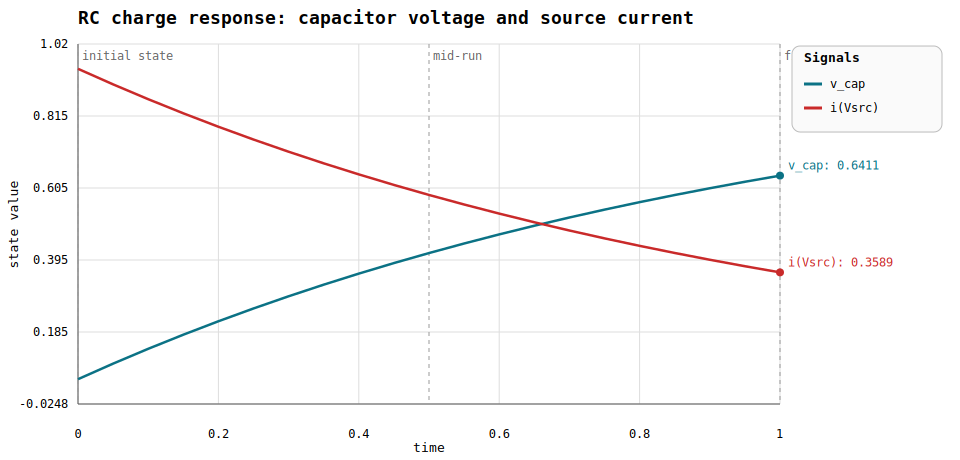

Final X: [0.9999999999999999, 0.6410576353590469, 0.35894236464095297]


In [11]:
rc_case = RC_CHARGE_CASE
rc_total_time = 1.0
rc_dt = 0.05

rc_history = run_transient_sequence(
    rc_case["base_node_n"],
    rc_case["netlist"],
    make_uniform_schedule(rc_total_time, rc_dt),
)

display(Markdown(render_result_table(rc_history, rc_case["node_labels"], max_rows=10)))
display(
    SVG(
        render_time_domain_svg(
            rc_history,
            [1, 2],
            rc_case["node_labels"],
            title="RC charge response: capacitor voltage and source current",
            annotations=[
                {"time": 0.0, "label": "initial state"},
                {"time": 0.5, "label": "mid-run"},
                {"time": rc_total_time, "label": "final sample"},
            ],
        )
    )
)
print("Final X:", rc_history["steps"][-1]["x_python"])

## RL Example

This case shows the branch-current unknown created for the inductor companion model.

Signals plotted:
- `v_L`: the voltage on the inductor-side node
- `i_L`: the inductor branch-current state

step | time | dt | latency | values
--- | --- | --- | --- | ---
0 | 0 | 0.05 | 431 | v_in=1, v_L=1.25, i(Vsrc)=-0.125, i_L=0.125
1 | 0.05 | 0.05 | 431 | v_in=1, v_L=1.5625, i(Vsrc)=-0.28125, i_L=0.28125
2 | 0.1 | 0.05 | 431 | v_in=1, v_L=1.95312, i(Vsrc)=-0.476562, i_L=0.476562
3 | 0.15 | 0.05 | 431 | v_in=1, v_L=2.44141, i(Vsrc)=-0.720703, i_L=0.720703
4 | 0.2 | 0.05 | 431 | v_in=1, v_L=3.05176, i(Vsrc)=-1.02588, i_L=1.02588
5 | 0.25 | 0.05 | 431 | v_in=1, v_L=3.8147, i(Vsrc)=-1.40735, i_L=1.40735
6 | 0.3 | 0.05 | 431 | v_in=1, v_L=4.76837, i(Vsrc)=-1.88419, i_L=1.88419
7 | 0.35 | 0.05 | 431 | v_in=1, v_L=5.96046, i(Vsrc)=-2.48023, i_L=2.48023
8 | 0.4 | 0.05 | 431 | v_in=1, v_L=7.45058, i(Vsrc)=-3.22529, i_L=3.22529
9 | 0.45 | 0.05 | 431 | v_in=1, v_L=9.31323, i(Vsrc)=-4.15661, i_L=4.15661
... | ... | ... | ... | 11 more rows

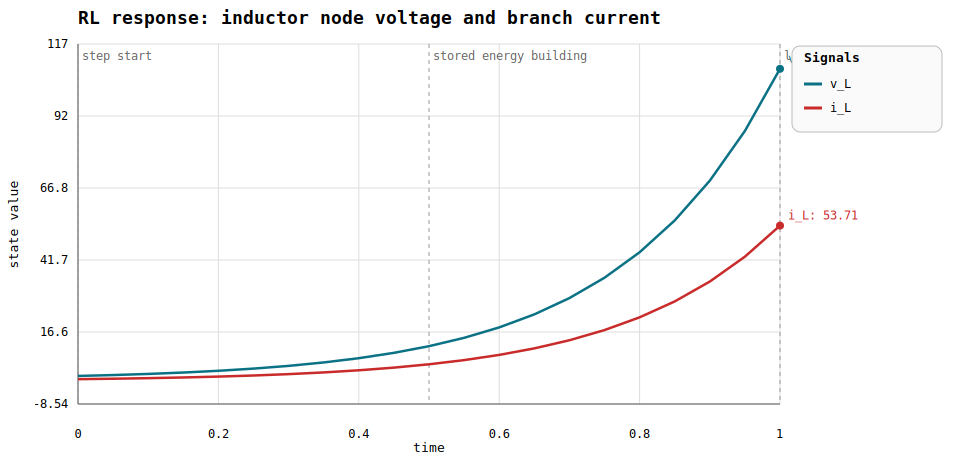

In [4]:
rl_case = RL_DRIVE_CASE
rl_history = run_transient_sequence(
    rl_case["base_node_n"],
    rl_case["netlist"],
    make_uniform_schedule(1.0, 0.05),
)

display(Markdown(render_result_table(rl_history, rl_case["node_labels"], max_rows=10)))
display(
    SVG(
        render_time_domain_svg(
            rl_history,
            [1, 3],
            rl_case["node_labels"],
            title="RL response: inductor node voltage and branch current",
            annotations=[
                {"time": 0.0, "label": "step start"},
                {"time": 0.5, "label": "stored energy building"},
                {"time": 1.0, "label": "late-time sample"},
            ],
        )
    )
)

## Sinusoidal Source Example

This checks the `sin_comb` path and makes it easy to inspect whether the source phase and frequency are being sampled the way you expect.

step | time | dt | latency | values
--- | --- | --- | --- | ---
0 | 0 | 0.025 | 114 | v_out=0, i(VSIN)=-0
1 | 0.025 | 0.025 | 114 | v_out=0.156434, i(VSIN)=0.0782172
2 | 0.05 | 0.025 | 114 | v_out=0.309017, i(VSIN)=0.154508
3 | 0.075 | 0.025 | 114 | v_out=0.45399, i(VSIN)=0.226995
4 | 0.1 | 0.025 | 114 | v_out=0.587785, i(VSIN)=0.293893
5 | 0.125 | 0.025 | 114 | v_out=0.707107, i(VSIN)=0.353553
6 | 0.15 | 0.025 | 114 | v_out=0.809017, i(VSIN)=0.404508
7 | 0.175 | 0.025 | 114 | v_out=0.891007, i(VSIN)=0.445503
8 | 0.2 | 0.025 | 114 | v_out=0.951057, i(VSIN)=0.475528
9 | 0.225 | 0.025 | 114 | v_out=0.987688, i(VSIN)=0.493844
10 | 0.25 | 0.025 | 114 | v_out=1, i(VSIN)=0.5
11 | 0.275 | 0.025 | 114 | v_out=0.987688, i(VSIN)=0.493844
... | ... | ... | ... | 29 more rows

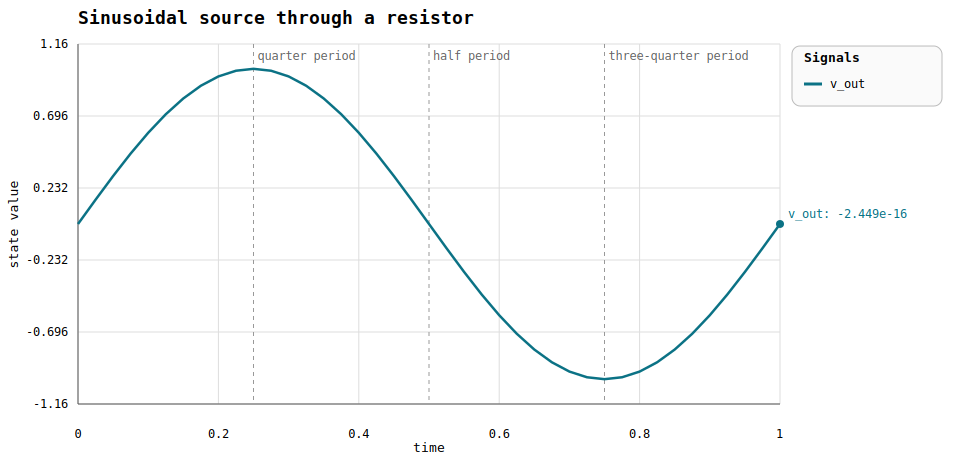

In [5]:
sin_case = VSIN_CASE
sin_history = run_transient_sequence(
    sin_case["base_node_n"],
    sin_case["netlist"],
    make_uniform_schedule(1.0, 0.025),
)

display(Markdown(render_result_table(sin_history, sin_case["node_labels"], max_rows=12)))
display(
    SVG(
        render_time_domain_svg(
            sin_history,
            [0],
            sin_case["node_labels"],
            title="Sinusoidal source through a resistor",
            annotations=[
                {"time": 0.25, "label": "quarter period"},
                {"time": 0.50, "label": "half period"},
                {"time": 0.75, "label": "three-quarter period"},
            ],
        )
    )
)

## PWM Voltage Source Example

This is the simplest square-wave source check. The waveform is piecewise constant, so it is a good visual test for the new `VPWM` stamp.

You can tune the low level, high level, period, and duty cycle directly in the case definition inside the helper module.

step | time | dt | latency | values
--- | --- | --- | --- | ---
0 | 0 | 0.05 | 108 | v_out=2.5, i(VPWM)=0.5
1 | 0.05 | 0.05 | 108 | v_out=2.5, i(VPWM)=0.5
2 | 0.1 | 0.05 | 108 | v_out=2.5, i(VPWM)=0.5
3 | 0.15 | 0.05 | 108 | v_out=2.5, i(VPWM)=0.5
4 | 0.2 | 0.05 | 108 | v_out=2.5, i(VPWM)=0.5
5 | 0.25 | 0.05 | 108 | v_out=2.5, i(VPWM)=0.5
6 | 0.3 | 0.05 | 108 | v_out=2.5, i(VPWM)=0.5
7 | 0.35 | 0.05 | 108 | v_out=0, i(VPWM)=-0
8 | 0.4 | 0.05 | 108 | v_out=0, i(VPWM)=-0
9 | 0.45 | 0.05 | 108 | v_out=0, i(VPWM)=-0
10 | 0.5 | 0.05 | 108 | v_out=0, i(VPWM)=-0
11 | 0.55 | 0.05 | 108 | v_out=0, i(VPWM)=-0
... | ... | ... | ... | 29 more rows

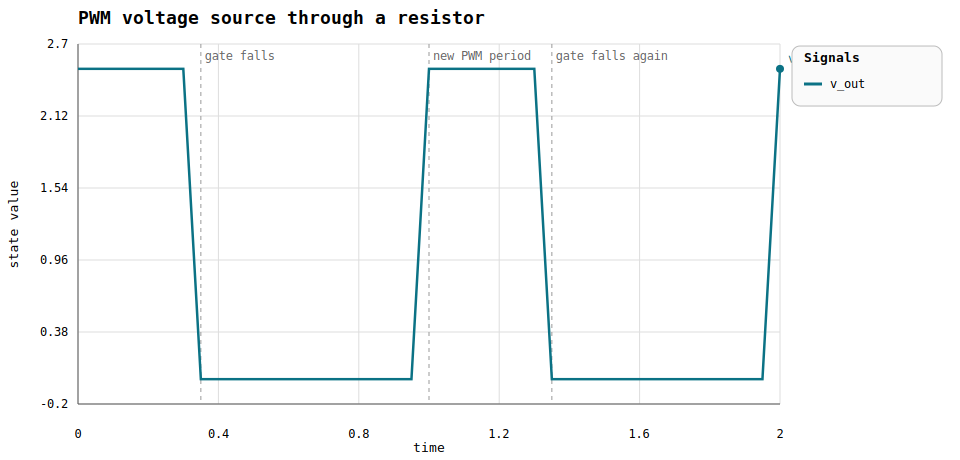

Final X: [2.5, 0.5]


In [6]:
vpwm_case = VPWM_CASE
vpwm_history = run_transient_sequence(
    vpwm_case["base_node_n"],
    vpwm_case["netlist"],
    make_uniform_schedule(2.0, 0.05),
)

display(Markdown(render_result_table(vpwm_history, vpwm_case["node_labels"], max_rows=12)))
display(
    SVG(
        render_time_domain_svg(
            vpwm_history,
            [0],
            vpwm_case["node_labels"],
            title="PWM voltage source through a resistor",
            annotations=[
                {"time": 0.35, "label": "gate falls"},
                {"time": 1.00, "label": "new PWM period"},
                {"time": 1.35, "label": "gate falls again"},
            ],
        )
    )
)
print("Final X:", vpwm_history["steps"][-1]["x_python"])

## PWM Switch Example

This demo uses `SWPWM` as a time-varying resistor. When the switch is on, the switching node is pulled hard toward ground; when it is off, the divider rises back toward the passive resistor ratio.

step | time | dt | latency | values
--- | --- | --- | --- | ---
0 | 0 | 0.05 | 227 | v_in=1, v_sw=0.0900901, i(Vsrc)=0.90991
1 | 0.05 | 0.05 | 227 | v_in=1, v_sw=0.0900901, i(Vsrc)=0.90991
2 | 0.1 | 0.05 | 227 | v_in=1, v_sw=0.0900901, i(Vsrc)=0.90991
3 | 0.15 | 0.05 | 227 | v_in=1, v_sw=0.0900901, i(Vsrc)=0.90991
4 | 0.2 | 0.05 | 227 | v_in=1, v_sw=0.0900901, i(Vsrc)=0.90991
5 | 0.25 | 0.05 | 227 | v_in=1, v_sw=0.0900901, i(Vsrc)=0.90991
6 | 0.3 | 0.05 | 227 | v_in=1, v_sw=0.0900901, i(Vsrc)=0.90991
7 | 0.35 | 0.05 | 227 | v_in=1, v_sw=0.0900901, i(Vsrc)=0.90991
8 | 0.4 | 0.05 | 227 | v_in=1, v_sw=0.0900901, i(Vsrc)=0.90991
9 | 0.45 | 0.05 | 227 | v_in=1, v_sw=0.0900901, i(Vsrc)=0.90991
10 | 0.5 | 0.05 | 227 | v_in=1, v_sw=0.908265, i(Vsrc)=0.0917348
11 | 0.55 | 0.05 | 227 | v_in=1, v_sw=0.908265, i(Vsrc)=0.0917348
... | ... | ... | ... | 29 more rows

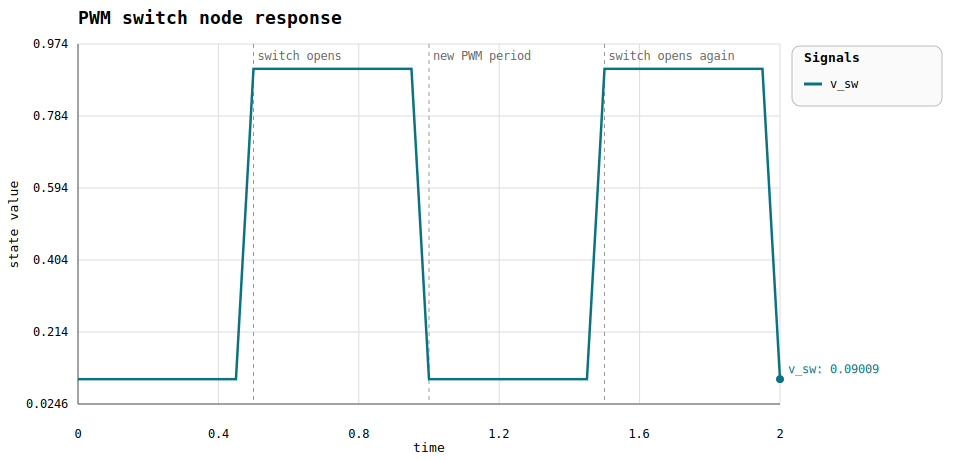

Low-phase and high-phase samples: [0.9999999999999999, 0.09009009009009009, 0.9099099099099098] [1.0, 0.9082652134423251, 0.09173478655767482]


In [7]:
switch_case = PWM_SWITCH_CASE
switch_history = run_transient_sequence(
    switch_case["base_node_n"],
    switch_case["netlist"],
    make_uniform_schedule(2.0, 0.05),
)

display(Markdown(render_result_table(switch_history, switch_case["node_labels"], max_rows=12)))
display(
    SVG(
        render_time_domain_svg(
            switch_history,
            [1],
            switch_case["node_labels"],
            title="PWM switch node response",
            annotations=[
                {"time": 0.50, "label": "switch opens"},
                {"time": 1.00, "label": "new PWM period"},
                {"time": 1.50, "label": "switch opens again"},
            ],
        )
    )
)
print("Low-phase and high-phase samples:", switch_history["steps"][2]["x_python"], switch_history["steps"][12]["x_python"])

## Switch-Driven RL Stage

This is a more boost-like test because it combines a source, an inductor, and a PWM-controlled switch. It is still not a full boost converter yet because there is no ideal diode or synchronous rectifier model in the kernel, but it already lets us inspect the switched inductor current evolution directly.

step | time | dt | latency | values
--- | --- | --- | --- | ---
0 | 0 | 0.02 | 419 | v_in=1, v_sw=-0.00786627, i(Vsrc)=-0.0806293, i_L=0.0806293
1 | 0.02 | 0.02 | 419 | v_in=1, v_sw=-0.0157944, i(Vsrc)=-0.161893, i_L=0.161893
2 | 0.04 | 0.02 | 419 | v_in=1, v_sw=-0.0237849, i(Vsrc)=-0.243796, i_L=0.243796
3 | 0.06 | 0.02 | 419 | v_in=1, v_sw=-0.0318383, i(Vsrc)=-0.326343, i_L=0.326343
4 | 0.08 | 0.02 | 419 | v_in=1, v_sw=-0.039955, i(Vsrc)=-0.409539, i_L=0.409539
5 | 0.1 | 0.02 | 419 | v_in=1, v_sw=-0.0481356, i(Vsrc)=-0.49339, i_L=0.49339
6 | 0.12 | 0.02 | 419 | v_in=1, v_sw=-0.0563805, i(Vsrc)=-0.5779, i_L=0.5779
7 | 0.14 | 0.02 | 419 | v_in=1, v_sw=-0.0646903, i(Vsrc)=-0.663076, i_L=0.663076
8 | 0.16 | 0.02 | 419 | v_in=1, v_sw=-0.0730655, i(Vsrc)=-0.748921, i_L=0.748921
9 | 0.18 | 0.02 | 419 | v_in=1, v_sw=-0.0815065, i(Vsrc)=-0.835441, i_L=0.835441
10 | 0.2 | 0.02 | 443 | v_in=1, v_sw=-5.35346, i(Vsrc)=-1.34372, i_L=1.34372
11 | 0.22 | 0.02 | 443 | v_in=1, v_sw=-8.32584, i(Vsrc)=-2.08978, i_L=2.08978
12 | 0.24 | 0.02 | 443 | v_in=1, v_sw=-12.6888, i(Vsrc)=-3.18489, i_L=3.18489
13 | 0.26 | 0.02 | 443 | v_in=1, v_sw=-19.0929, i(Vsrc)=-4.79232, i_L=4.79232
14 | 0.28 | 0.02 | 443 | v_in=1, v_sw=-28.4931, i(Vsrc)=-7.15177, i_L=7.15177
... | ... | ... | ... | 36 more rows

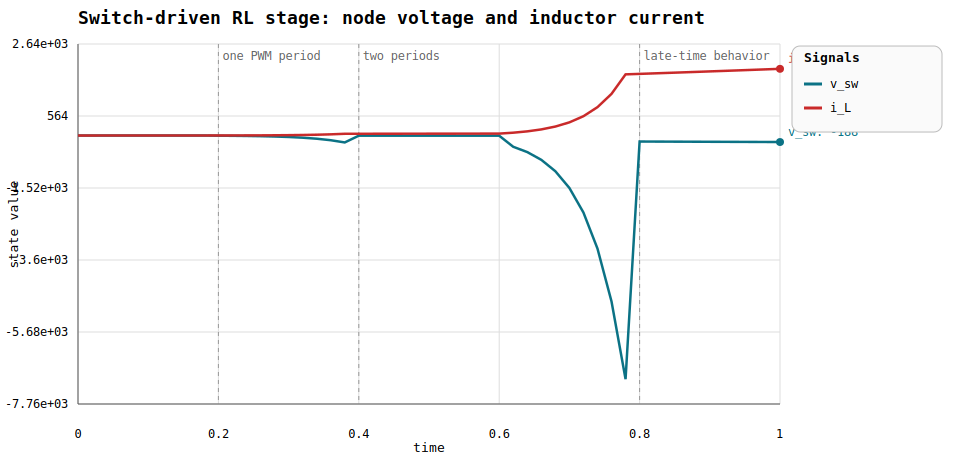

In [8]:
boost_lite_case = BOOST_LITE_CASE
boost_lite_history = run_transient_sequence(
    boost_lite_case["base_node_n"],
    boost_lite_case["netlist"],
    make_uniform_schedule(1.0, 0.02),
)

display(Markdown(render_result_table(boost_lite_history, boost_lite_case["node_labels"], max_rows=15)))
display(
    SVG(
        render_time_domain_svg(
            boost_lite_history,
            [1, 3],
            boost_lite_case["node_labels"],
            title="Switch-driven RL stage: node voltage and inductor current",
            annotations=[
                {"time": 0.20, "label": "one PWM period"},
                {"time": 0.40, "label": "two periods"},
                {"time": 0.80, "label": "late-time behavior"},
            ],
        )
    )
)

## Variable-`dt` Demo

This cell uses the same RC case but changes timestep size during the run. It is useful for visually checking that the kernel really consumes `par_dt` each step rather than assuming a fixed integration interval.

step | time | dt | latency | values
--- | --- | --- | --- | ---
0 | 0 | 0.1 | 219 | v_in=1, v_cap=0.0909091, i(Vsrc)=0.909091
1 | 0.1 | 0.1 | 219 | v_in=1, v_cap=0.173554, i(Vsrc)=0.826446
2 | 0.2 | 0.05 | 219 | v_in=1, v_cap=0.212908, i(Vsrc)=0.787092
3 | 0.25 | 0.05 | 219 | v_in=1, v_cap=0.250389, i(Vsrc)=0.749611
4 | 0.3 | 0.2 | 219 | v_in=1, v_cap=0.375324, i(Vsrc)=0.624676
5 | 0.5 | 0.2 | 219 | v_in=1, v_cap=0.479437, i(Vsrc)=0.520563
6 | 0.7 | 0.1 | 219 | v_in=1, v_cap=0.526761, i(Vsrc)=0.473239
7 | 0.8 | 0.1 | 219 | v_in=1, v_cap=0.569782, i(Vsrc)=0.430218

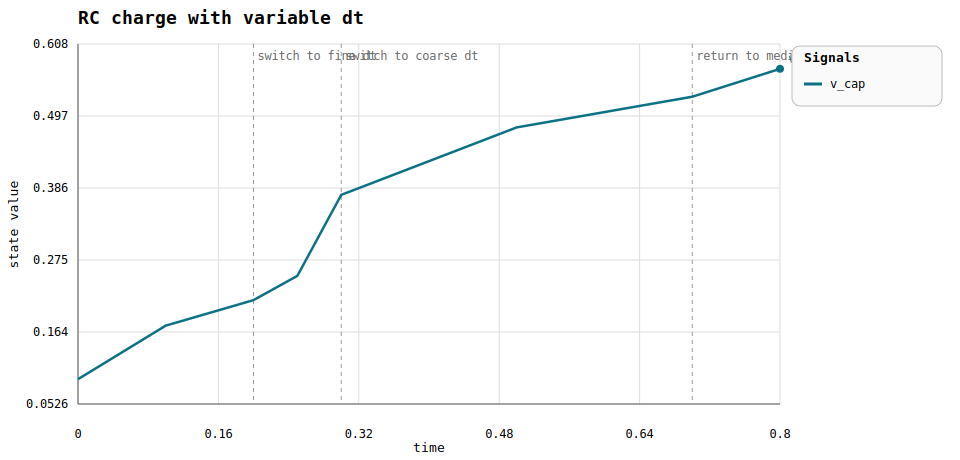

[0.1, 0.1, 0.05, 0.05, 0.2, 0.2, 0.1, 0.1]


In [9]:
variable_dt_history = run_transient_sequence(
    RC_CHARGE_CASE["base_node_n"],
    RC_CHARGE_CASE["netlist"],
    VARIABLE_DT_SCHEDULE,
)

display(Markdown(render_result_table(variable_dt_history, RC_CHARGE_CASE["node_labels"], max_rows=20)))
display(
    SVG(
        render_time_domain_svg(
            variable_dt_history,
            [1],
            RC_CHARGE_CASE["node_labels"],
            title="RC charge with variable dt",
            annotations=[
                {"time": 0.20, "label": "switch to fine dt"},
                {"time": 0.30, "label": "switch to coarse dt"},
                {"time": 0.70, "label": "return to medium dt"},
            ],
        )
    )
)
print([step['dt'] for step in variable_dt_history['steps']])